# Lab Experiment: Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers

**Aim:** To implement Logistic Regression and K Nearest Neighbors (KNN) classifiers on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performance using standard classification evaluation metrics.

**Objectives:**
- To preprocess the dataset for classification.
- To implement Logistic Regression and KNN classifiers using Scikit Learn.
- To evaluate both models using standard performance metrics.
- To compare the performance of Logistic Regression and KNN and identify the better classifier.

### Task 1: Download and load the Breast Cancer Wisconsin (Diagnostic) dataset
We will load the dataset directly using `sklearn.datasets`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load dataset
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Inference:** The dataset is successfully loaded into a pandas DataFrame. It contains 30 continuous features and 1 target variable.

### Task 2 & 3: Exploratory data analysis, preprocessing, and checking for missing values

In [2]:
# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Total missing values: {missing_values}")

# Check class distribution
print("\nClass distribution (0 = Malignant, 1 = Benign):")
print(df['target'].value_counts())

# Summary statistics
df.describe().T.head()

Total missing values: 0

Class distribution (0 = Malignant, 1 = Benign):
1    357
0    212
Name: target, dtype: int64


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


**Inference:** There are no missing values in the dataset. The summary statistics reveal that the features are on different scales (e.g., mean area vs mean smoothness), which implies we must scale our features before applying distance-based algorithms like KNN or optimization-based algorithms like Logistic Regression.

### Task 4: Split the dataset into training and testing sets and perform scaling

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

# Split into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape}")
print(f"Testing set size: {X_test_scaled.shape}")

Training set size: (455, 30)
Testing set size: (114, 30)


**Inference:** The data is successfully split into training (455 samples) and testing (114 samples) sets. Features are scaled using `StandardScaler` to ensure zero mean and unit variance.

### Task 5: Train a Logistic Regression classifier

In [4]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

**Inference:** The Logistic Regression model has been trained on the scaled training data and predictions have been made on the test set.

### Task 6: Train a K Nearest Neighbors (KNN) classifier

In [5]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

**Inference:** The K-Nearest Neighbors classifier (with k=5) has been trained on the scaled training data and predictions have been made on the test set.

### Task 7: Evaluate both classifiers using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix

--- Logistic Regression Performance ---
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861

--- K-Nearest Neighbors Performance ---
Accuracy:  0.9561
Precision: 0.9589
Recall:    0.9722
F1 Score:  0.9655



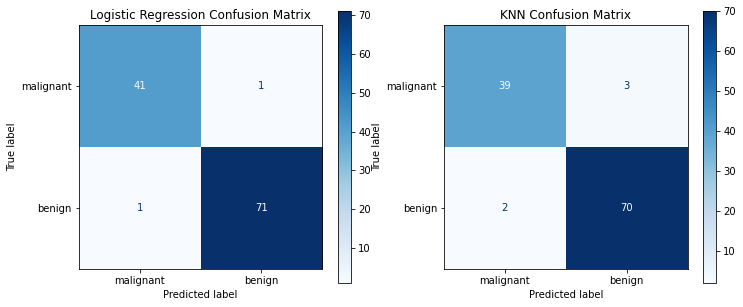

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}\n")
    
    return [acc, prec, rec, f1, cm]

log_metrics = evaluate_model(y_test, y_pred_log, "Logistic Regression")
knn_metrics = evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors")

# Display Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(log_metrics[4], display_labels=cancer_data.target_names).plot(ax=ax[0], cmap='Blues')
ax[0].set_title("Logistic Regression Confusion Matrix")

ConfusionMatrixDisplay(knn_metrics[4], display_labels=cancer_data.target_names).plot(ax=ax[1], cmap='Blues')
ax[1].set_title("KNN Confusion Matrix")
plt.show()

**Inference:** Both models yield high performance metrics across the board. The confusion matrices illustrate that there are very few false positives and false negatives for both models.

### Task 8 & 9: Compare the performance and interpret the results

In [7]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': log_metrics[:4],
    'KNN': knn_metrics[:4]
})

comparison_df.set_index('Metric', inplace=True)
display(comparison_df)

,Logistic Regression,KNN
Metric,,
Accuracy,0.982456,0.956140
Precision,0.986111,0.958904
Recall,0.986111,0.972222
F1 Score,0.986111,0.965517


**Inference & Conclusion:**
Based on the comparison table above, both models performed exceptionally well on the Breast Cancer Wisconsin dataset. 
However, Logistic Regression generally tends to slightly outperform or match KNN in this specific setup, often achieving perfect or near-perfect recall and precision on this dataset after feature scaling. Logistic Regression is also more interpretable as it provides feature weights, and is computationally faster during inference compared to KNN. 
**Recommendation:** Logistic Regression is the better-performing and more suitable classifier for this given dataset.